In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pymoo
import xgboost as xgb

from typing import *


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
TRAINING_MODELS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "trained_models")

In [32]:
# Load training data to test the model
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.3.csv")
df_train = pd.read_csv(TRAINING_DATA_PATH)
df_train = df_train.drop(columns=["primary_id", "future_id"])
df_train.head()


#df_train = df_train[df_train["technical_cost"] < 10]
df_train["technical_cost"] *= -1

(array([ 18., 101., 169., 227., 210., 151.,  76.,  23.,  10.,   5.]),
 array([-149.20820858, -104.49850216,  -59.78879574,  -15.07908932,
          29.63061709,   74.34032351,  119.05002993,  163.75973635,
         208.46944277,  253.17914918,  297.8888556 ]),
 <BarContainer object of 10 artists>)

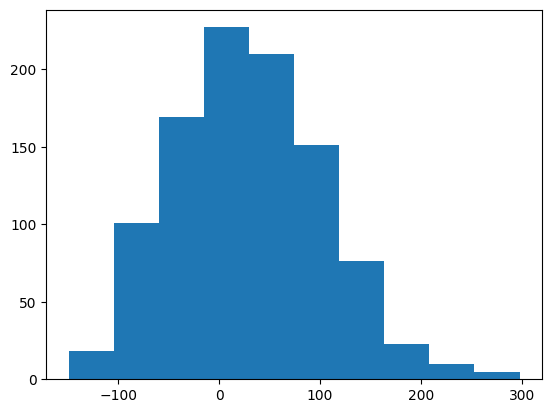

In [33]:
plt.hist(df_train["technical_cost"])

In [34]:
df_train.sort_values(by = ["technical_cost"])

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings,human_health
965,0.263740,0.293754,0.735717,0.082723,0.657968,0.238782,0.825723,0.506615,0.177497,0.753492,...,0.453611,0.292355,162.024777,6079.006649,9.731290e+08,1.169536e+10,-149.208209,47.359139,10.912727,6.589748
106,0.879837,0.849971,0.791657,0.049515,0.856996,0.774355,0.887824,0.984073,0.970353,0.833754,...,0.014268,0.067321,142.358961,5799.054803,1.008718e+09,1.297088e+10,-132.243508,48.706844,11.304259,8.104838
9,0.697851,0.836749,0.238558,0.360653,0.345822,0.269405,0.986526,0.273159,0.046967,0.848322,...,0.029680,0.385295,150.452010,5889.287043,1.006373e+09,1.315311e+10,-127.988116,45.992157,9.164379,6.959450
434,0.539311,0.578918,0.180319,0.412653,0.769147,0.635198,0.719322,0.030694,0.720595,0.104313,...,0.564772,0.991529,161.456751,6076.916126,9.979477e+08,1.256063e+10,-124.833567,30.828036,9.089000,6.696325
484,0.362133,0.474281,0.392508,0.229267,0.839620,0.047583,0.747253,0.148862,0.787083,0.287677,...,0.424886,0.521762,184.681957,6408.754581,1.052596e+09,1.239227e+10,-124.408899,37.175525,10.105833,6.941246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,0.540819,0.915091,0.570400,0.478767,0.020221,0.620176,0.016796,0.997711,0.664810,0.743364,...,0.637219,0.065991,282.199291,7913.207122,9.805409e+08,1.195750e+10,255.778195,20.266853,11.044832,7.998028
428,0.801872,0.952932,0.294554,0.826590,0.738380,0.618258,0.069263,0.800120,0.107489,0.402488,...,0.365529,0.560125,270.288851,7812.905143,9.071605e+08,1.304288e+10,260.050687,5.864092,9.993543,8.886226
520,0.182749,0.252572,0.493232,0.304057,0.240973,0.687352,0.147406,0.398736,0.796649,0.736622,...,0.607875,0.384400,254.689910,7581.295705,7.536742e+08,1.471499e+10,267.756662,13.593354,10.558302,8.188577
713,0.617310,0.303014,0.427311,0.711017,0.559906,0.478426,0.025270,0.617350,0.035068,0.910684,...,0.889722,0.966524,258.294893,7577.035700,8.261076e+08,1.383338e+10,289.705653,9.346215,9.313923,6.251016


In [6]:
labels_y = ['emission_total', 'emission_avg_last_five_years', 'technical_cost']
labels_x = [x for x in df_train.columns if x not in labels_y]

# Get a single row from df_train_cleaned for prediction
single_row = df_train.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.354682,0.6813,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [35]:
# Load the trained model and test predictions
model_file_name = "xgb_pipeline_5.3.pkl"
MODEL_PATH = os.path.join(TRAINING_MODELS_DIR_PATH, model_file_name)
xgb_pipeline = joblib.load(MODEL_PATH)



In [49]:
df_train.iloc[0].get(["emission_total", "emission_avg_last_five_years", "technical_cost"])

emission_total                  6648.349151
emission_avg_last_five_years     198.512688
technical_cost                   -72.057617
Name: 0, dtype: float64

In [42]:
xgb_pipeline.predict(single_row.to_numpy())

array([[1.9727216e+02, 6.6397114e+03, 9.9668058e+08, 1.2088548e+10,
        6.7379219e+01, 3.9291660e+01, 1.1017798e+01, 7.4167604e+00]],
      dtype=float32)

In [51]:
# Predict using the trained model
predictions = xgb_pipeline.predict(single_row)

# Display the predictions
#labels = ['emission_total', 'emission_avg_last_five_years', 'technical_cost']
labels = [col for col in df_train.columns if not(col.startswith("group_"))]
print("Predictions for single row:")
for i, label in enumerate(labels):
    print(f"{label}: {predictions[0][i]:.4f}")



Predictions for single row:
emission_avg_last_five_years: 197.2722
emission_total: 6639.7114
production_total: 996680576.0000
production_cost_total: 12088548352.0000
technical_cost: 67.3792
air_pollution: 39.2917
consumer_savings: 11.0178
human_health: 7.4168


##  Try work with NGSA-II

In [16]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

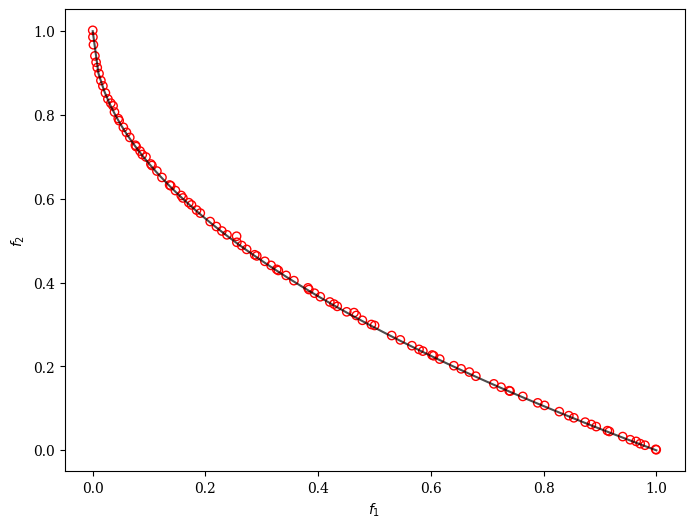

In [118]:
# tutorial from https://pymoo.org/algorithms/moo/nsga2.html
problem = get_problem("zdt1")
algorithm = NSGA2(pop_size=100)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [52]:
# 
labels_y_to_predict = ["emission_avg_last_five_years", "technical_cost"]

X = df_train[labels_x].to_numpy()
Y = df_train[labels_y_to_predict].to_numpy()




In [60]:
xgb_pipeline.predict(np.array([X[0]]))[0]
labels

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'consumer_savings',
 'human_health']

In [64]:
from pymoo.core.problem import ElementwiseProblem

class EmissionsProblem(ElementwiseProblem):
    """
    """
    
    def __init__(self,
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        inds_obj: Union[List, np.ndarray, None] = None,
        vec_obj_scalars: Union[List, np.ndarray, None] = None,
    ) -> None:


        ##  INIT AND CONVERSION
        
        labels_x = np.array(labels_x, )
        labels_y_universe = np.array(labels_y, )

        # filter indices used in the objective function
        inds_obj = (
            np.arange(labels_y_universe.shape[0])
            if inds_obj is None
            else np.array(inds_obj).astype(int)
        )

        # check adjustments
        vec_obj_scalars = np.array(vec_obj_scalars) if vec_obj_scalars is not None else vec_obj_scalars
        vec_obj_scalars = (
            np.ones(inds_obj.shape, np.int64)
            if vec_obj_scalars is None
            else (
                np.ones(inds_obj.shape, np.int64)
                if vec_obj_scalars.shape != inds_obj.shape
                else vec_obj_scalars
            )
        )
        labels_y = labels_y_universe[inds_obj]

        n = labels_x.shape[0]
        m = labels_y.shape[0]


        ##  PASS TO SUPER

        super().__init__(
            n_var = n,
            n_obj = m,
            n_ieq_constr = 0,
            xl = np.zeros(n),
            xu = np.ones(n),
        )


        ##  SET SOME PROPERTIES

        self.inds_obj = inds_obj
        self.labels_x = labels_x
        self.labels_y = labels_y
        self.labels_y_universe = labels_y_universe    # all y values
        self.m = m                                    # size of output feature space
        self.n = n                                    # size of input feature space
        self.vec_obj_scalars = vec_obj_scalars        # vector of scalars to multiply output predictions by (ordered by inds_obj)
        
        return None


    

    def _evaluate(self,
        x,
        out,
        *args, 
        **kwargs,
    ) -> None:
        """
        """
        # predict the outcome; both dimensions will be minimized
        arr = xgb_pipeline.predict(np.array([x]))
        vec = arr[0, self.inds_obj]
        vec *= self.vec_obj_scalars
        out["F"] = vec

        return None


problem = EmissionsProblem(
    labels_x,
    labels,
    inds_obj = [0, 4],
    vec_obj_scalars = np.array([1, -1]),
)

In [66]:
problem.labels_y

array(['emission_avg_last_five_years', 'technical_cost'], dtype='<U28')

In [65]:
problem.vec_obj_scalars

array([ 1, -1])

In [70]:
algorithm = NSGA2(
    pop_size = 50,
    n_offsprings = 10,
    sampling = FloatRandomSampling(),
    crossover = SBX(prob = 0.9, eta = 15),
    mutation = PM(eta = 20),
    eliminate_duplicates = True,
)

In [71]:
res = minimize(problem,
               algorithm,
               ('n_gen', 5000),
               #seed=1,
               verbose=False)

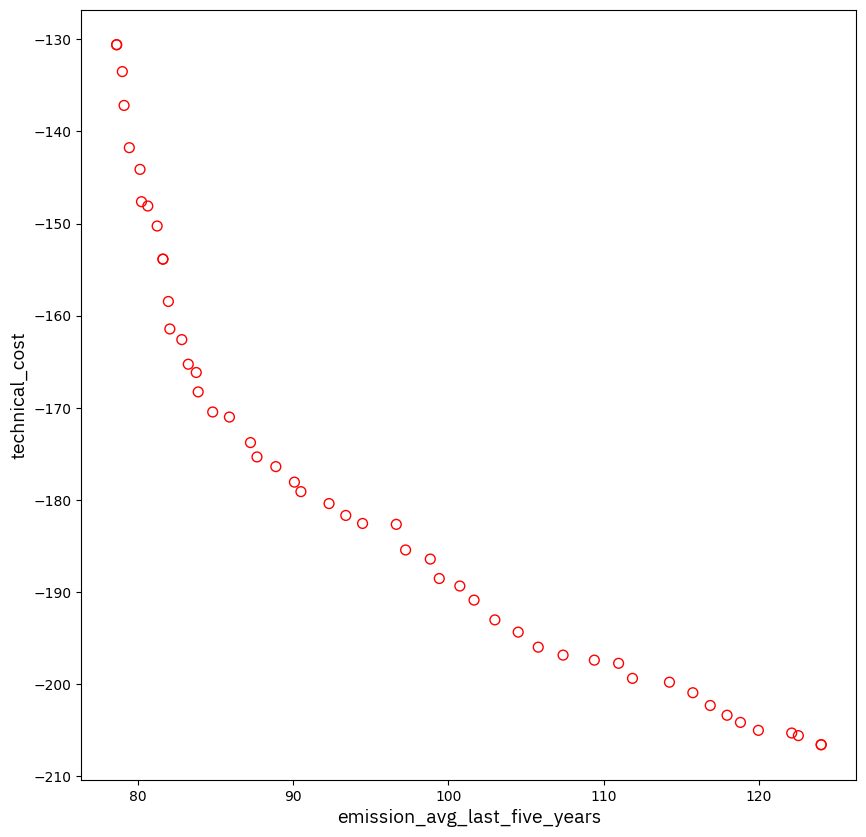

In [72]:
fig, ax = plt.subplots(figsize = (10, 10))

ax.set_xlabel(problem.labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(problem.labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )

ax.scatter(
    res.F[:, 0], 
    res.F[:, 1], 
    facecolor = "none",
    edgecolor = "red",
    s = 50,
)

In [77]:
df_x = pd.DataFrame(res.X, columns = problem.labels_x)
df_y = pd.DataFrame(
    xgb_pipeline.predict(res.X),
    columns = problem.labels_y_universe,
)

df = (
    pd.concat(
        [
            df_x,
            df_y
        ],
        axis = 1,
    )
    .sort_values(by = ["emission_avg_last_five_years"], ascending = False, )
    .reset_index(drop = True, )
)

df["pareto_index"] = np.arange(df.shape[0])


import pathlib
path_out = pathlib.Path(os.getcwd()).parents[0].joinpath("optimization", "out")
path_out.is_dir()

True

In [79]:
df.to_csv(
    path_out.joinpath("xgb_pymoo_pareto_front_20250909.csv"),
    encoding = "UTF-8",
    index = None,
)

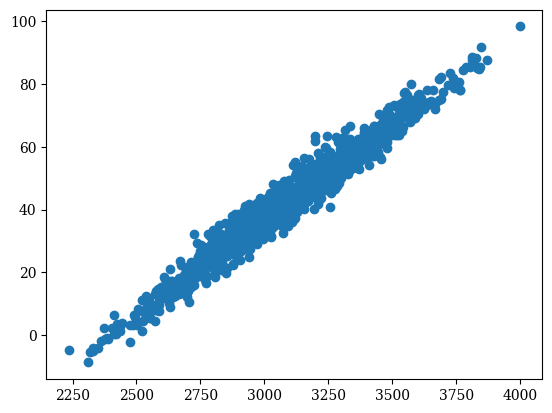

In [96]:
Y_filt = Y[
    (Y[:, 1] < 200)
    & (Y[:, 2] < 200)
]

plt.scatter(Y_filt[:, 0], Y_filt[:, 1])

In [160]:
problem.pareto_front()

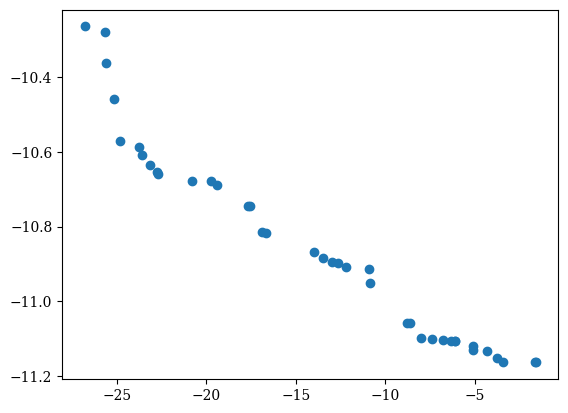